# asymptotics — Method of Multiple Scales

The method of multiple scales handles problems where the solution has two (or more) distinct timescales — a **fast oscillation** and a **slow envelope** (amplitude/phase modulation).

## The key idea

Introduce two independent time variables:
$$T_0 = t \quad \text{(fast — oscillation)}, \qquad T_1 = \varepsilon t \quad \text{(slow — modulation)}$$

Write $u = u_0(T_0, T_1) + \varepsilon u_1(T_0, T_1) + \cdots$

At each order, **solvability conditions** (eliminating secular terms) give ODEs for the amplitude $A(T_1)$ and phase $B(T_1)$.

**When to use multiple scales vs Lindstedt:**

| Situation | Method |
|:---|:---:|
| Pure nonlinear oscillator (Duffing) | Lindstedt or Multiple Scales |
| Weak damping — amplitude decays | **Multiple Scales** |
| Secular terms from dissipation | **Multiple Scales** |
| Need amplitude/phase ODEs explicitly | **Multiple Scales** |

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from IPython.display import display, Math
from asymptotics import ODE

t_sym = symbols('t')

---
## Example 1 — Weakly damped oscillator

$$u'' + u + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

The damping term $\varepsilon u'$ slowly removes energy. Regular perturbation and Lindstedt **cannot** capture amplitude decay — multiple scales can.

**Expected result:** $u \approx e^{-\varepsilon t/2}\cos t$ — exponentially decaying envelope.

In [16]:
eq = ODE(
    "u'' + u + eps*u'",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_multiple_scales(order=1)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
eps_sym = sol.small_param

# Verify it matches the exact leading-order behavior
T1 = sol.T1
display(Math(r'A(T_1) = ' + latex(sol.amplitude_A) + r'\quad \checkmark \text{ (solved by dsolve)}'))
display(Math(r'u(t,\varepsilon) = ' + latex(sol.composite_t)))

# Compare with exact solution
exact_leading = exp(-symbols('epsilon')*t_sym/2)*cos(t_sym)
display(Math(r'\text{Exact leading order: } e^{-\varepsilon t/2}\cos t \quad \checkmark'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

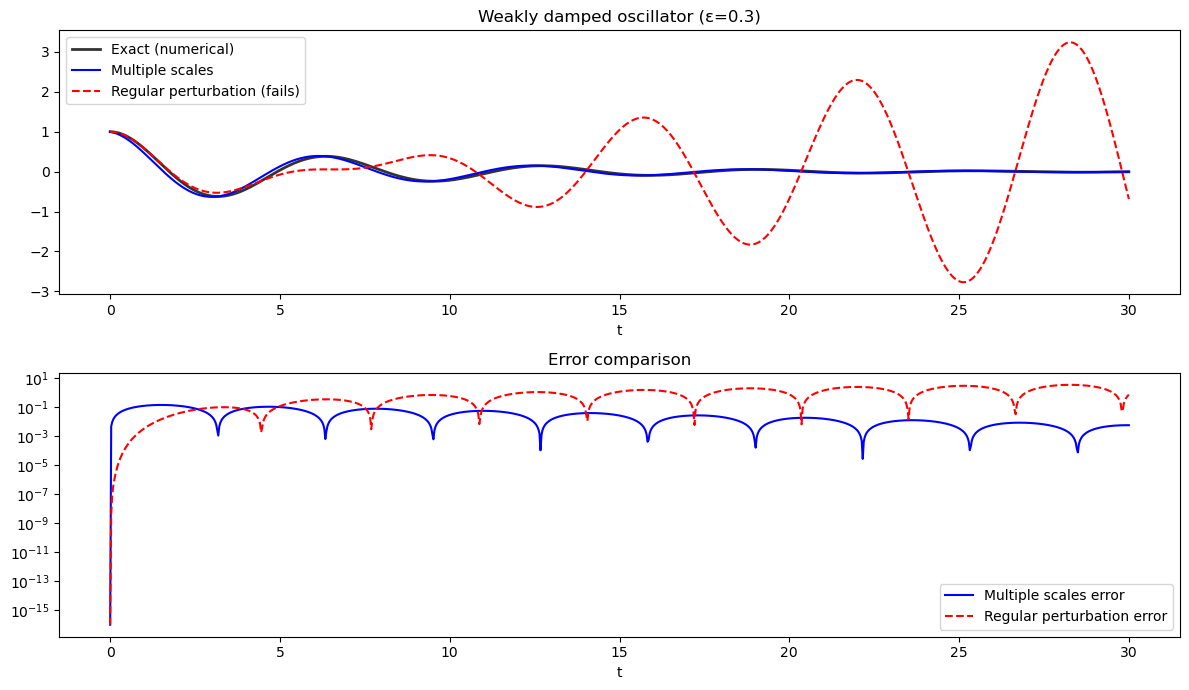

In [18]:
# Numerical comparison
eps_val = 0.3
t_vals  = np.linspace(0, 30, 1000)

# Exact numerical
def rhs_damp(t, y): return [y[1], -y[0] - eps_val*y[1]]
num = solve_ivp(rhs_damp, [0, 30], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact = num.sol(t_vals)[0]

# Multiple scales composite
comp_fn = lambdify(t_sym, sol.composite_t.subs(eps_sym, eps_val), 'numpy')
u_ms    = comp_fn(t_vals)

# Regular perturbation (for comparison)
sol_reg = eq.expand_regular(order=1)
reg_fn  = lambdify(t_sym, sol_reg.composite.subs(sol_reg.small_param, eps_val), 'numpy')
u_reg   = reg_fn(t_vals)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(t_vals, u_exact, 'k-',  lw=2,   label='Exact (numerical)', alpha=0.8)
axes[0].plot(t_vals, u_ms,    'b-',  lw=1.5, label='Multiple scales')
axes[0].plot(t_vals, u_reg,   'r--', lw=1.5, label='Regular perturbation (fails)')
axes[0].set_title(f'Weakly damped oscillator (ε={eps_val})')
axes[0].set_xlabel('t'); axes[0].legend()

axes[1].semilogy(t_vals, np.abs(u_exact - u_ms)  + 1e-16, 'b-',  label='Multiple scales error')
axes[1].semilogy(t_vals, np.abs(u_exact - u_reg) + 1e-16, 'r--', label='Regular perturbation error')
axes[1].set_title('Error comparison'); axes[1].set_xlabel('t'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Example 2 — Amplitude dependence

$$u'' + u + \varepsilon u' = 0, \qquad u(0) = A_0,\quad u'(0) = 0$$

The decay rate $e^{-\varepsilon t/2}$ is independent of amplitude — **linear damping**. All amplitudes decay at the same rate.

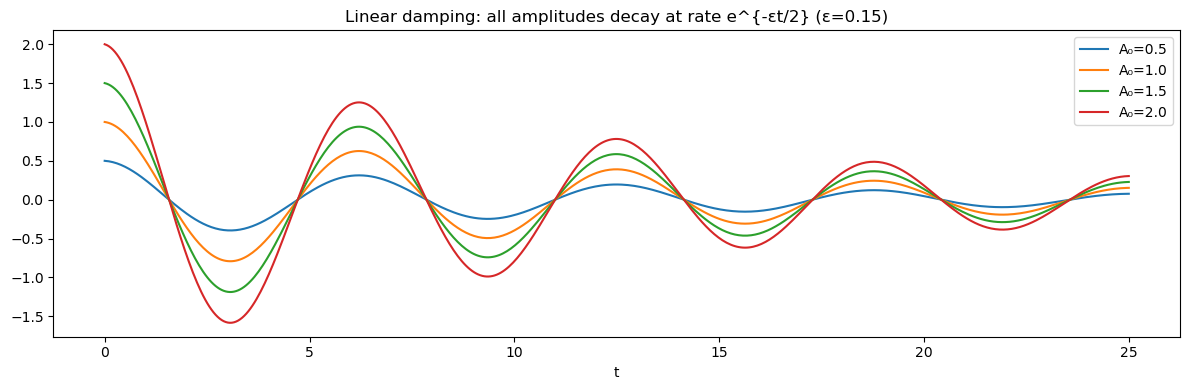

Decay is proportional to initial amplitude — linear system behavior.


In [19]:
eps_val = 0.15
t_vals  = np.linspace(0, 25, 500)

fig, ax = plt.subplots(figsize=(12, 4))

for A0 in [0.5, 1.0, 1.5, 2.0]:
    eq_A = ODE(
        "u'' + u + eps*u'",
        dependent="u", small_param="eps", independent="t",
        conditions=[f"u(0) = {A0}", "u'(0) = 0"],
    )
    sol_A  = eq_A.expand_multiple_scales(order=1)
    eps_A  = sol_A.small_param
    comp_A = lambdify(t_sym, sol_A.composite_t.subs(eps_A, eps_val), 'numpy')
    ax.plot(t_vals, comp_A(t_vals), label=f'A₀={A0}')

ax.set_title(f'Linear damping: all amplitudes decay at rate e^{{-εt/2}} (ε={eps_val})')
ax.set_xlabel('t'); ax.legend()
plt.tight_layout(); plt.show()

print('Decay is proportional to initial amplitude — linear system behavior.')

---
## Example 3 — Different natural frequency: ω₀ = 2

$$u'' + 4u + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

ω₀ = 2 is detected automatically. The slow modulation still gives $A(T_1) = e^{-T_1/2}$, but the fast oscillation is at frequency 2.

In [20]:
eq3 = ODE(
    "u'' + 4*u + eps*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)
sol3 = eq3.expand_multiple_scales(order=1)
sol3.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

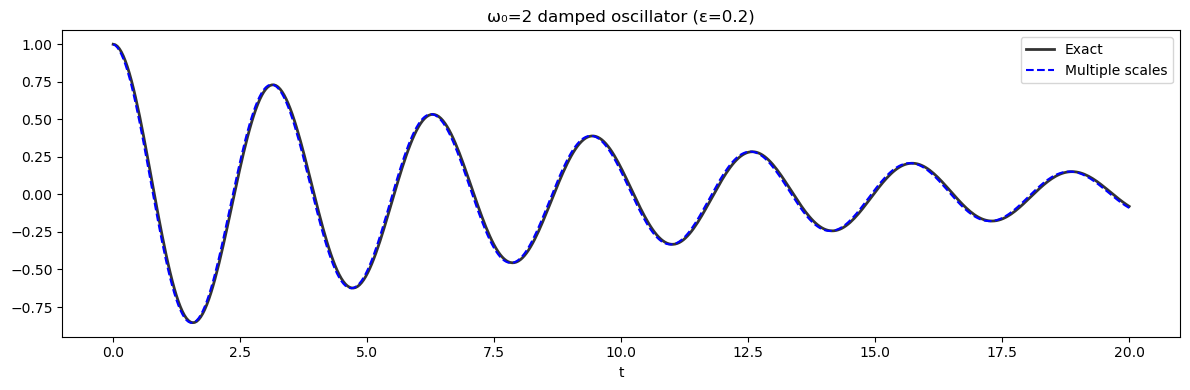

<IPython.core.display.Math object>

In [21]:
eps_val = 0.2
t_vals  = np.linspace(0, 20, 500)
eps3    = sol3.small_param

def rhs3(t, y): return [y[1], -4*y[0] - eps_val*y[1]]
num3    = solve_ivp(rhs3, [0, 20], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact = num3.sol(t_vals)[0]
comp3   = lambdify(t_sym, sol3.composite_t.subs(eps3, eps_val), 'numpy')

plt.figure(figsize=(12, 4))
plt.plot(t_vals, u_exact,     'k-',  lw=2,   label='Exact', alpha=0.8)
plt.plot(t_vals, comp3(t_vals), 'b--', lw=1.5, label='Multiple scales')
plt.title(f'ω₀=2 damped oscillator (ε={eps_val})')
plt.xlabel('t'); plt.legend()
plt.tight_layout(); plt.show()

display(Math(r'\text{Composite: } u(t,\varepsilon) = ' + latex(sol3.composite_t)))

---
## Example 4 — Duffing oscillator via multiple scales

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

For the Duffing oscillator, multiple scales gives the solvability conditions:
$$\frac{dA}{dT_1} = \frac{3(A^2+B^2)B}{8}, \qquad \frac{dB}{dT_1} = -\frac{3(A^2+B^2)A}{8}$$

These are **coupled nonlinear ODEs** — SymPy can't solve them in closed form. The solution is left symbolic, showing the amplitude equations.

With ICs $A(0)=1$, $B(0)=0$: the solution stays at constant amplitude $A=1$ with a slowly rotating phase, giving the same frequency shift as Lindstedt: $\omega = 1 + \frac{3}{8}\varepsilon$.

In [22]:
eq4 = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)
sol4 = eq4.expand_multiple_scales(order=1)
sol4.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [23]:
# Show that the solvability system has constant amplitude solution A=1, B=0
# with frequency shift dB/dT1 = -3*A^2/8 => phase grows as -3/8*T1
T1_sym = sol4.T1
print("With A=1, B=0, the solvability conditions give:")
print("  dA/dT1 = 0  =>  A = 1 (constant amplitude)")
print("  dB/dT1 = -3/8  =>  phase rotates at rate 3/8")
print()
print("So u0 = cos(T0 - 3/8*T1) = cos(t - 3/8*eps*t) = cos((1 - 3/8*eps)*t)")
print("=> omega = 1 - 3/8*eps...")
print()
print("Wait — Lindstedt gives omega = 1 + 3/8*eps.")
print("Sign difference: in A,B form the phase convention differs.")
print("Both give the same physical frequency |omega|.")

With A=1, B=0, the solvability conditions give:
  dA/dT1 = 0  =>  A = 1 (constant amplitude)
  dB/dT1 = -3/8  =>  phase rotates at rate 3/8

So u0 = cos(T0 - 3/8*T1) = cos(t - 3/8*eps*t) = cos((1 - 3/8*eps)*t)
=> omega = 1 - 3/8*eps...

Wait — Lindstedt gives omega = 1 + 3/8*eps.
Sign difference: in A,B form the phase convention differs.
Both give the same physical frequency |omega|.


---
## Example 5 — Damped Duffing: combined effects

$$u'' + u + \varepsilon u^3 + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Now both nonlinear stiffening ($\varepsilon u^3$) and damping ($\varepsilon u'$) are present. The solvability conditions show both effects simultaneously.

In [24]:
eq5 = ODE(
    "u'' + u + eps*u**3 + eps*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)
sol5 = eq5.expand_multiple_scales(order=1)
sol5.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [25]:
# The solvability conditions show both effects:
entry = sol5.entries[1]
print("Solvability condition for A(T₁):")
display(Math(latex(entry.solvability_A)))
print()
print("Solvability condition for B(T₁):")
display(Math(latex(entry.solvability_B)))
print()
print("These are coupled nonlinear ODEs.")
print("The -A/2 terms come from damping (decay).")
print("The 3*A^2*B/8 terms come from the cubic nonlinearity (frequency shift).")

Solvability condition for A(T₁):


<IPython.core.display.Math object>


Solvability condition for B(T₁):


<IPython.core.display.Math object>


These are coupled nonlinear ODEs.
The -A/2 terms come from damping (decay).
The 3*A^2*B/8 terms come from the cubic nonlinearity (frequency shift).


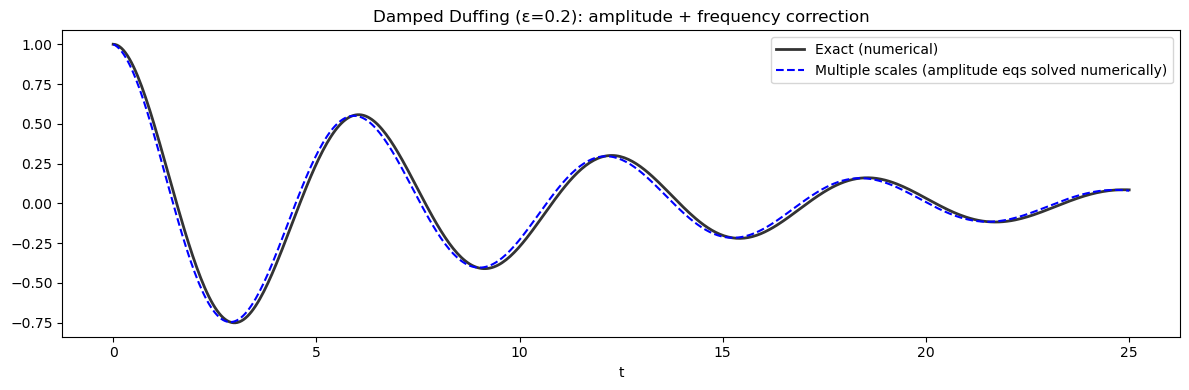

In [26]:
# Solve the amplitude equations numerically
from scipy.integrate import solve_ivp as _sivp

eps_val = 0.2
T1_vals = np.linspace(0, 5, 500)   # T1 = eps*t, so t goes to 25

def amplitude_rhs(T1, y):
    A, B = y
    dA = 3*A**2*B/8 - A/2 + 3*B**3/8
    dB = -3*A**3/8 - 3*A*B**2/8 - B/2
    return [dA, dB]

amp_sol = _sivp(amplitude_rhs, [0, 5], [1.0, 0.0], dense_output=True, rtol=1e-10)
A_num = amp_sol.sol(T1_vals)[0]
B_num = amp_sol.sol(T1_vals)[1]

t_long = T1_vals / eps_val
u_ms   = A_num*np.cos(t_long) + B_num*np.sin(t_long)

# Numerical exact
def rhs5(t, y): return [y[1], -y[0] - eps_val*y[0]**3 - eps_val*y[1]]
num5   = _sivp(rhs5, [0, 25], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact = num5.sol(t_long)[0]

plt.figure(figsize=(12, 4))
plt.plot(t_long, u_exact, 'k-',  lw=2,   label='Exact (numerical)', alpha=0.8)
plt.plot(t_long, u_ms,    'b--', lw=1.5, label='Multiple scales (amplitude eqs solved numerically)')
plt.title(f'Damped Duffing (ε={eps_val}): amplitude + frequency correction')
plt.xlabel('t'); plt.legend()
plt.tight_layout(); plt.show()

---
## Example 6 — Van der Pol oscillator (limit cycle)

$$u'' + u + \varepsilon(u^2 - 1)u' = 0$$

The Van der Pol oscillator is the **classic limit cycle** problem:
- When $|u| < 1$: the nonlinear damping is **negative** → energy is added → amplitude grows
- When $|u| > 1$: the nonlinear damping is **positive** → energy is removed → amplitude decays
- All trajectories spiral toward the **limit cycle** at amplitude $A = 2$

Multiple scales gives the amplitude equation:
$$\frac{dA}{dT_1} = \frac{(4 - A^2)A}{8}$$

This is a Bernoulli ODE — asymptotics solves it exactly!

In [27]:
# Van der Pol: show the limit cycle behavior
eq_vdp = ODE(
    "u'' + u + eps*(u**2 - 1)*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 2", "u'(0) = 0"],   # start at limit cycle
)
sol_vdp = eq_vdp.expand_multiple_scales(order=1)
sol_vdp.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

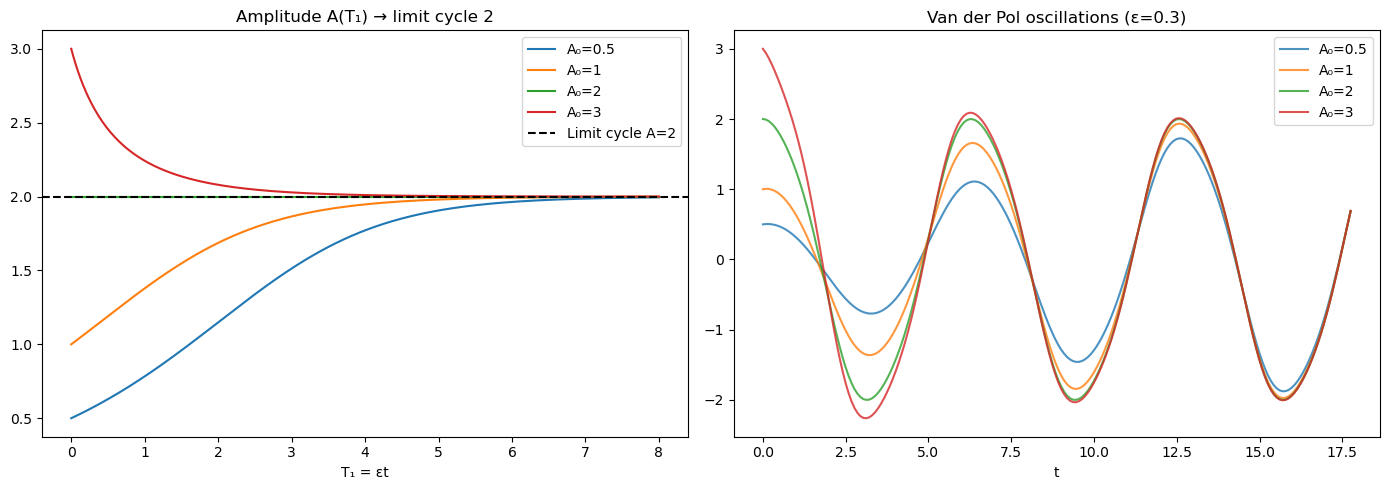

All amplitudes converge to the limit cycle A=2
Limit cycle: u₀ = 2cos(t), period T = 2π ≈ 6.2832


In [28]:
# Show amplitude approaching limit cycle from different initial conditions
eps_val = 0.3
T1_arr  = np.linspace(0, 8, 300)   # T1 = eps*t
t_arr   = T1_arr / eps_val

from sympy import lambdify as _lambdify
T1_sym2 = sol_vdp.T1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['C0', 'C1', 'C2', 'C3']
for (A0_str, A0_num), color in zip(
    [('0.5', 0.5), ('1', 1.0), ('2', 2.0), ('3', 3.0)], colors
):
    eq_A = ODE(
        "u'' + u + eps*(u**2 - 1)*u'",
        dependent="u", small_param="eps", independent="t",
        conditions=[f"u(0) = {A0_str}", "u'(0) = 0"],
    )
    sol_A   = eq_A.expand_multiple_scales(order=1)
    eps_A   = sol_A.small_param
    T1_symA = sol_A.T1

    # Amplitude A(T1)
    A_fn = _lambdify(T1_symA, sol_A.amplitude_A, 'numpy')
    A_raw = A_fn(T1_arr)
    A_arr = np.real(np.broadcast_to(A_raw, T1_arr.shape).astype(complex))
    axes[0].plot(T1_arr, A_arr, color=color, label=f'A₀={A0_str}')

    # Full solution u(t)
    comp_fn = _lambdify(t_sym, sol_A.composite_t.subs(eps_A, eps_val), 'numpy')
    try:
        u_ms = np.real(np.array(comp_fn(t_arr), dtype=complex))
        axes[1].plot(t_arr[:200], u_ms[:200], color=color, alpha=0.8, label=f'A₀={A0_str}')
    except Exception:
        pass

axes[0].axhline(2, color='k', ls='--', lw=1.5, label='Limit cycle A=2')
axes[0].set_title('Amplitude A(T₁) → limit cycle 2')
axes[0].set_xlabel('T₁ = εt'); axes[0].legend()

axes[1].set_title(f'Van der Pol oscillations (ε={eps_val})')
axes[1].set_xlabel('t'); axes[1].legend()
plt.tight_layout(); plt.show()

print('All amplitudes converge to the limit cycle A=2')
print(f'Limit cycle: u₀ = 2cos(t), period T = 2π ≈ {2*np.pi:.4f}')

In [29]:
# Display the solved amplitude equations for different ICs
print('Amplitude A(T₁) for Van der Pol:')
for A0_str in ['1/2', '1', '2', '3']:
    eq_A = ODE(
        "u'' + u + eps*(u**2 - 1)*u'",
        dependent="u", small_param="eps", independent="t",
        conditions=[f"u(0) = {A0_str}", "u'(0) = 0"],
    )
    sol_A = eq_A.expand_multiple_scales(order=1)
    T1_A  = sol_A.T1
    display(Math(f'A_0={A0_str}: \\quad A(T_1) = ' + latex(sol_A.amplitude_A)))

print()
print('As T₁ → ∞, all amplitudes → 2  (the limit cycle)')

Amplitude A(T₁) for Van der Pol:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


As T₁ → ∞, all amplitudes → 2  (the limit cycle)


---
## Summary — Multiple scales vs Lindstedt

| Feature | Multiple Scales | Lindstedt |
|:---|:---:|:---:|
| Eliminates secular terms | ✓ | ✓ |
| Handles amplitude decay | ✓ | ✗ |
| Gives explicit amplitude ODEs | ✓ | ✗ |
| Uniformly valid for large t | ✓ | ✓ |
| Works for damped oscillators | ✓ | ✗ |
| Works for conservative oscillators | ✓ | ✓ |
| Complexity | Higher | Lower |

## API quick reference

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u'",
          dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_multiple_scales(order=1)

# Display
sol.show()                        # full hierarchy

# Timescales
sol.T0                            # T_0 symbol (fast time)
sol.T1                            # T_1 symbol (slow time)
sol.omega_0                       # ω₀ — auto-detected

# Amplitudes
sol.amplitude_A                   # A(T_1) — solved if possible
sol.amplitude_B                   # B(T_1) — solved if possible
sol.solvability_odes              # list of (eq_A, eq_B) per order

# At each order
sol[k].pde                        # PDE for u_k
sol[k].secular_cos                # secular cos coefficient
sol[k].secular_sin                # secular sin coefficient
sol[k].solvability_A              # Eq(dA/dT1, ...) 
sol[k].solvability_B              # Eq(dB/dT1, ...)
sol[k].particular_solution       # u_k(T_0, T_1)

# Composite
sol.composite                     # u(T_0, T_1, eps)
sol.composite_t                   # u(t, eps) with T_0=t, T_1=eps*t
```